# Ladder Model

We want to test a new matchmaking system for the AI Arena StarCraft 2 bot ladder. To do this, we need a model of the ladder that can simulate match outcomes and durations for any pair of bots.

The model must handle two regimes:

- **Data-rich match-ups:** where we have historical results between two specific bots.
- **Data-poor match-ups:** where we must fall back to ELO-based predictions.

We use Bayesian inference to smoothly blend the two, with the ELO-based prediction as the prior and observed match data as evidence.

## Ratings Updates

The expected score $E_\text{A}$ of a match between bots A and B (from A's perspective) with ratings $R_\text{A}$ and $R_\text{B}$ is given as

$$
E_\text{A} = \frac{1}{1 + 10^{\frac{R_\text{B} - R_\text{A}}{400}}}
$$

and update rule for bot A is

$$
\Delta R_\text{A} = K \cdot ( S_\text{A} - E_\text{A} ),
$$

where $K$ is the adjustment per game (set to 16 on AI Arena) and $S_\text{A}$ is A's actual score of the match (1 for a win, 0.5 for a draw and 0 for a loss).

The expected score $E_\text{A}$ is only a proxy for A's win probability if there is no possibility for a draw.
In the bot games of AI Arena, we frequently encounter draws, and we need to model them.

Additionally, ratings on AI Arena are often **not transitive**, i.e. A beating B almost surely and B beating C a.s. does not imply A beating C a.s. (which the ELO system assumes). For this reason, where we have data available we should use it to inform the outcome of a simulated match.
To get a smooth transition between no-data to data match-ups, we use the ELO system estimate (augmented with a global draw rate, $d$) as the prior and perform Bayesian inference with actual data, where available.

## Two-Stage Simulation

On AI Arena, not every match plays out normally. We distinguish three **game categories**:

- **Normal game:** plays to completion in under 60 minutes, producing a win, loss, or draw.
- **Time-limit draw:** the game reaches the hard 60-minute cap (80,640 game steps). Always recorded as a draw.
- **Abnormal termination:** a bot crashes or stops responding mid-game. The surviving bot wins by default. These have different duration characteristics than normal games.

For each simulated match, we first sample the category, then conditionally sample the outcome and duration:

1. **Category** $\sim \text{Dir}(\boldsymbol{\alpha}_\text{category})$ — normal, time-limit, or abnormal.
2. **If normal:** outcome $\sim \text{Dir}(\boldsymbol{\alpha}_\text{outcome})$, duration $\sim \text{LogNormal}(\mu, \sigma^2)$ truncated at 60 min.
3. **If time-limit:** outcome is draw, duration is 60 minutes.
4. **If abnormal:** the crashing bot loses (deterministic), duration $\sim \text{LogNormal}(\mu_\text{abn}, \sigma_\text{abn}^2)$ using global parameters only (too sparse per matchup for Bayesian updating).

This means the outcome model and normal duration model are fitted on **normal games only**, and the draw rate $d$ refers to the normal-game draw rate.

## Match Outcome Model

For normal games, we model the outcome with a 3-dimensional Dirichlet distribution, updated with the observed number of normal-game wins ($W$), losses ($L$) and draws ($D$):

$$
\begin{aligned}
&P_\text{A}^\text{ELO}(\text{win}) = (1 - d) \cdot E_\text{A},\\
&P_\text{A}^\text{ELO}(\text{loss}) = (1 - d) \cdot (1 - E_\text{A}),\\
&P_\text{A}^\text{ELO}(\text{draw}) = d;
\end{aligned}
$$

$$
\boldsymbol{\alpha}_\text{outcome} = \big(n_0 \cdot P_\text{A}^\text{ELO}(\text{win}) + W, \quad n_0 \cdot P_\text{A}^\text{ELO}(\text{draw}) + D, \quad n_0 \cdot P_\text{A}^\text{ELO}(\text{loss}) + L\big),
$$

$$
(p_\text{win},\, p_\text{draw},\, p_\text{loss}) \sim \text{Dir}(\boldsymbol{\alpha}_\text{outcome}),
$$

where $n_0$ determines the strength of the prior (in units of number of matches). In the following I will use $n_0 = 5$, which means that if we have real data for 5 matches, we consider the evidence from the real data as strong as the prior.

The plot below compares the ELO prior ($E_\text{A}$) against the Bayesian posterior mean for predicting win rates. The posterior is visibly tighter around the diagonal, confirming that the Bayesian update improves calibration over the raw ELO prediction. Circle size is proportional to the number of observed games.

In [5]:
import numpy as np
import pandas as pd
from plotly.subplots import make_subplots
import plotly.graph_objects as go

matchups = pd.read_csv("ladder_model/matchup_params.csv")
df = matchups.copy()
df["total_normal"] = df["W"] + df["L"] + df["D"]
df = df[df["total_normal"] >= 10]
df["observed_winrate"] = df["W"] / df["total_normal"]
df["loss_rate"] = df["L"] / df["total_normal"]
df["posterior_winrate"] = df["alpha_win"] / (df["alpha_win"] + df["alpha_draw"] + df["alpha_loss"])
df["posterior_lossrate"] = df["alpha_loss"] / (df["alpha_win"] + df["alpha_draw"] + df["alpha_loss"])
n = len(df)

# Each pair contributes two points: the canonical (bot_lo) perspective and
# the mirror (bot_hi) perspective. Canonicalization by bot_id is not
# rating-symmetric, so plotting only one direction makes the scatter biased
# relative to the inherently symmetric calibration.
text_lo = df["bot_lo_name"] + " vs " + df["bot_hi_name"]
text_hi = df["bot_hi_name"] + " vs " + df["bot_lo_name"]
marker_sizes = np.log1p(df["total_normal"]) * 3

x_elo = np.concatenate([df["E_A"].values, 1 - df["E_A"].values])
y_elo = np.concatenate([df["observed_winrate"].values, df["loss_rate"].values])
x_post = np.concatenate([df["posterior_winrate"].values, df["posterior_lossrate"].values])
y_post = y_elo
text_all = np.concatenate([text_lo.values, text_hi.values])
sizes_all = np.concatenate([marker_sizes.values, marker_sizes.values])
marker = dict(size=sizes_all, opacity=0.5)

fig = make_subplots(rows=1, cols=2, subplot_titles=["ELO Prior", "Bayesian Posterior"])

fig.add_trace(go.Scatter(
    x=x_elo, y=y_elo, mode="markers", marker=marker, text=text_all,
    hovertemplate="%{text}<br>Predicted: %{x:.2f}<br>Observed: %{y:.2f}<extra></extra>",
    showlegend=False,
), row=1, col=1)
fig.add_trace(go.Scatter(
    x=[0, 1], y=[0, 1], mode="lines", line=dict(dash="dash", color="gray"),
    name="Perfect calibration",
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=x_post, y=y_post, mode="markers", marker=marker, text=text_all,
    hovertemplate="%{text}<br>Predicted: %{x:.2f}<br>Observed: %{y:.2f}<extra></extra>",
    showlegend=False,
), row=1, col=2)
fig.add_trace(go.Scatter(
    x=[0, 1], y=[0, 1], mode="lines", line=dict(dash="dash", color="gray"),
    showlegend=False,
), row=1, col=2)

fig.update_xaxes(title_text="Expected win rate (ELO predicted)", row=1, col=1)
fig.update_xaxes(title_text="E[p_win] (posterior mean)", row=1, col=2)
fig.update_yaxes(title_text="Observed win rate", row=1, col=1)
fig.update_yaxes(title_text="Observed win rate", row=1, col=2)
fig.update_layout(title=f"Win Rate Calibration (matchups with ≥10 normal games, n={n} pairs × 2 directions)", width=2000, height=1000)#, width=1000, height=450)
fig.show()#renderer="png")

## Game Category Model

The category probability is modelled with a 3-dimensional Dirichlet, using the global category rates as prior:

$$
\boldsymbol{\alpha}_\text{category} = \big(n_0 \cdot p_\text{normal} + N_\text{normal}, \quad n_0 \cdot p_\text{timelimit} + N_\text{timelimit}, \quad n_0 \cdot p_\text{abnormal} + N_\text{abnormal}\big),
$$

$$
(p_\text{norm},\, p_\text{tl},\, p_\text{abn}) \sim \text{Dir}(\boldsymbol{\alpha}_\text{category}),
$$

where $N_\text{normal}$, $N_\text{timelimit}$, and $N_\text{abnormal}$ are the observed counts for the match-up, and $p_\text{normal}$, $p_\text{timelimit}$, $p_\text{abnormal}$ are the global category fractions.

## Match Duration Model

For normal games, match durations are positive and right-skewed. We model them with a log-normal distribution truncated at 60 minutes:

$$
\log(\text{duration}) \sim \mathcal{N}(\mu, \sigma^2), \quad \text{duration} < 60.
$$

The truncation ensures that the duration model cannot produce games at the time limit, which are already handled by the time-limit category. In practice, since the log-normal is fitted on normal games (all shorter than 60 minutes), the truncation rarely rejects a sample.

The global parameters $\mu_0$ and $\sigma^2$ are fitted from the log-transformed durations of all normal games. For a specific match-up with $n$ observed normal-game durations with sample mean $\bar{x}$ (in log-space), the posterior mean is

$$
\mu_\text{duration} = \frac{n_0 \cdot \mu_0 + n \cdot \bar{x}}{n_0 + n},
$$

with posterior uncertainty $\sigma_\text{duration} = \sigma / \sqrt{n_0 + n}$. The variance $\sigma^2$ is kept fixed at the global estimate.

### Abnormal Game Duration

For abnormal terminations, durations are modelled with a separate log-normal using global parameters only ($\mu_\text{abn}$, $\sigma_\text{abn}$), since per-matchup crash data is too sparse for meaningful Bayesian updating.

The plot below shows the global duration fit for normal games. On the left, the log-transformed durations are compared to the fitted normal distribution; on the right, the same fit in the original time scale.

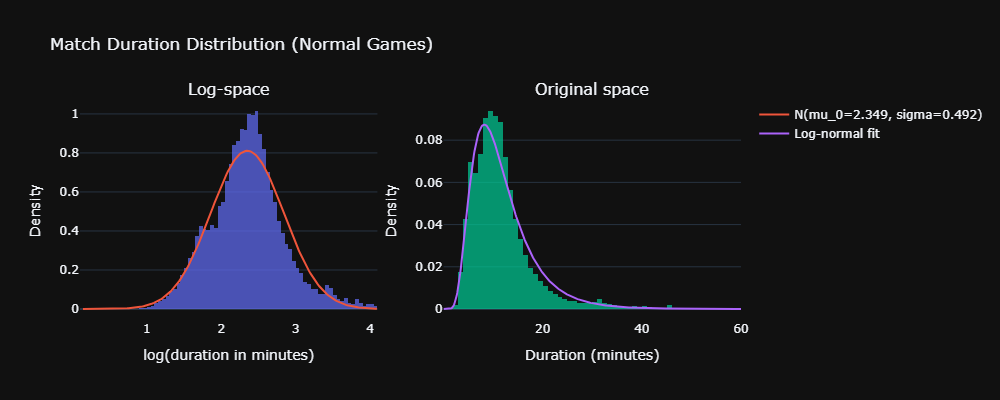

In [5]:
import json
import numpy as np
import pandas as pd
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from scipy import stats

matches = pd.read_csv("ladder_data/matches.csv")
with open("ladder_model/global_params.json") as f:
    gp = json.load(f)

# Filter to normal games with valid duration
INVALID = {"InitializationError", "MatchCancelled", "Error"}
ABNORMAL = {"Player1Crash", "Player2Crash", "Player1TimeOut", "Player2TimeOut"}
normal = matches[~matches["result_type"].isin(INVALID | ABNORMAL) & (matches["is_timeout"] == False)]
dur = normal["duration_minutes"].dropna()
dur = dur[dur > 0]
log_dur = np.log(dur.values)

mu_0, sigma = gp["mu_0"], gp["sigma"]

fig = make_subplots(rows=1, cols=2, subplot_titles=["Log-space", "Original space"])

# Left: log-duration + normal fit
fig.add_trace(go.Histogram(
    x=log_dur, nbinsx=100, histnorm="probability density",
    name="Observed", opacity=0.7, showlegend=False,
), row=1, col=1)
x_log = np.linspace(log_dur.min(), log_dur.max(), 200)
fig.add_trace(go.Scatter(
    x=x_log, y=stats.norm.pdf(x_log, mu_0, sigma),
    mode="lines", name=f"N(mu_0={mu_0:.3f}, sigma={sigma:.3f})",
    line=dict(width=2),
), row=1, col=1)

# Right: duration + log-normal fit
fig.add_trace(go.Histogram(
    x=dur.values, nbinsx=100, histnorm="probability density",
    name="Observed", opacity=0.7, showlegend=False,
), row=1, col=2)
x_dur = np.linspace(0.01, 60, 500)
fig.add_trace(go.Scatter(
    x=x_dur, y=stats.lognorm.pdf(x_dur, s=sigma, scale=np.exp(mu_0)),
    mode="lines", name="Log-normal fit", line=dict(width=2),
), row=1, col=2)

fig.update_xaxes(title_text="log(duration in minutes)", row=1, col=1)
fig.update_xaxes(title_text="Duration (minutes)", row=1, col=2)
fig.update_yaxes(title_text="Density", row=1, col=1)
fig.update_yaxes(title_text="Density", row=1, col=2)
fig.update_layout(title="Match Duration Distribution (Normal Games)", width=1000, height=400)
fig.show(renderer="png")